<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/DeepLearning/Deep_Learning_Weight_Initialization_Advanced_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Weight Initialization

In [ ]:
import numpy as np
import math

In [ ]:
rng = np.random.default_rng(0)

In [ ]:
x = rng.normal(0,0.1,size=(512,100))
x.shape

(512, 100)

### Comparing Vanishing vs. Exploding Activations

Let's visualize the standard deviation of activations across layers for both scenarios (small weights leading to vanishing activations and large weights leading to exploding activations) to clearly see the differences.

In [ ]:
# Re-run simulation for vanishing activations and collect stds
vanishing_stds = []
current_input = x
for i in range(5):
  W_small = rng.normal(0, 0.01, size=(100,100))
  z = current_input @ W_small
  a = np.maximum(0, z)
  vanishing_stds.append(a.std())
  current_input = a

print(f"Vanishing activation stds: {vanishing_stds}")

Vanishing activation stds: [np.float64(0.005802286411098925), np.float64(0.00040653463032898314), np.float64(2.831214810059948e-05), np.float64(1.802508219012698e-06), np.float64(1.3753005367173032e-07)]


In [ ]:
# Re-run simulation for exploding activations and collect stds
exploding_stds = []
current_input = x
for i in range(5):
  W_large = rng.normal(0, 1.0, size=(100,100))
  z = current_input @ W_large
  a = np.maximum(0, z)
  exploding_stds.append(a.std())
  current_input = a

print(f"Exploding activation stds: {exploding_stds}")

Exploding activation stds: [np.float64(0.5878923342124027), np.float64(4.256153810112021), np.float64(29.349234453395535), np.float64(204.18984968418928), np.float64(1412.6461179143475)]


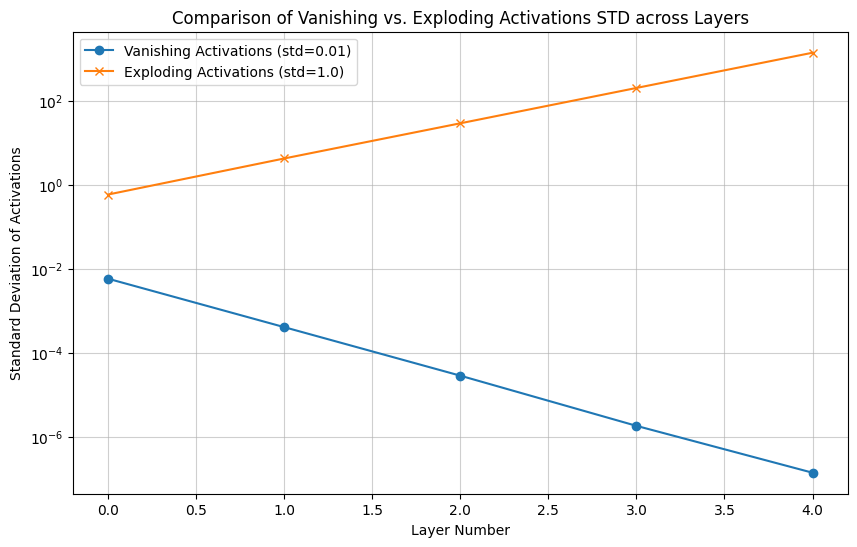

In [ ]:
import matplotlib.pyplot as plt

layers = range(len(vanishing_stds))

plt.figure(figsize=(10, 6))
plt.plot(layers, vanishing_stds, label='Vanishing Activations (std=0.01)', marker='o')
plt.plot(layers, exploding_stds, label='Exploding Activations (std=1.0)', marker='x')

plt.title('Comparison of Vanishing vs. Exploding Activations STD across Layers')
plt.xlabel('Layer Number')
plt.ylabel('Standard Deviation of Activations')
plt.yscale('log') # Use a log scale for better visualization due to large differences
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

### Simulating Forward Pass with He Initialization

He initialization is designed to work well with ReLU activations by scaling weights such that the variance of activations remains consistent across layers. For a layer with `fan_in` input connections, weights are sampled from a normal distribution with mean 0 and standard deviation `sqrt(2 / fan_in)`.

In [ ]:
# Simulate forward pass using He Initialization and collect stds
he_stds = []
current_input = x

fan_in = 100 # Assuming 100 input features, matching the 'x' shape
std_he = math.sqrt(2.0 / fan_in)

print(f"He initialization standard deviation: {std_he:.4f}")

for i in range(5):
  W_he = rng.normal(0, std_he, size=(100,100))
  z = current_input @ W_he
  a = np.maximum(0, z) # ReLU activation
  he_stds.append(a.std())
  current_input = a

print(f"He activation stds: {he_stds}")

He initialization standard deviation: 0.1414
He activation stds: [np.float64(0.08411503933087641), np.float64(0.08297260693813535), np.float64(0.08260604301931249), np.float64(0.08607683794522115), np.float64(0.07421940313316785)]


### Simulating Forward Pass with Xavier (Glorot) Initialization

Xavier initialization is designed for activation functions that are symmetric around zero, like `tanh` or `sigmoid`. For a layer with `fan_in` input connections and `fan_out` output connections, weights are sampled from a distribution with variance `1 / (fan_in + fan_out)`.

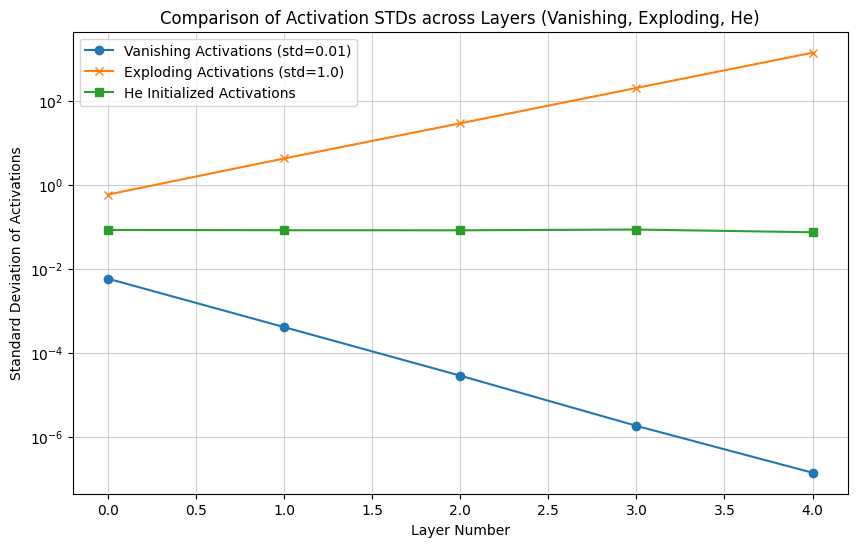

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(layers, vanishing_stds, label='Vanishing Activations (std=0.01)', marker='o')
plt.plot(layers, exploding_stds, label='Exploding Activations (std=1.0)', marker='x')
plt.plot(layers, he_stds, label='He Initialized Activations', marker='s')

plt.title('Comparison of Activation STDs across Layers (Vanishing, Exploding, He)')
plt.xlabel('Layer Number')
plt.ylabel('Standard Deviation of Activations')
plt.yscale('log') # Use a log scale for better visualization due to large differences
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

In [ ]:
# Simulate forward pass using Xavier Initialization and collect stds
xavier_stds = []
current_input = x

fan_in = 100 # Input features for the layer
fan_out = 100 # Output features for the layer

# Calculate the limit for uniform distribution based on Xavier formula
# For uniform: sqrt(6 / (fan_in + fan_out))
limit_xavier = math.sqrt(6.0 / (fan_in + fan_out))

print(f"Xavier initialization limit (uniform): {limit_xavier:.4f}")

for i in range(5):
  # Xavier uniform initialization samples from [-limit, limit]
  W_xavier = rng.uniform(-limit_xavier, limit_xavier, size=(fan_in, fan_out))
  z = current_input @ W_xavier

  # Note: Xavier was designed for tanh/sigmoid, but we'll use ReLU for direct comparison
  # with He, as per the existing simulation setup.
  a = np.maximum(0, z) # ReLU activation
  xavier_stds.append(a.std())
  current_input = a

print(f"Xavier activation stds: {xavier_stds}")

Xavier initialization limit (uniform): 0.1732
Xavier activation stds: [np.float64(0.05843766193517395), np.float64(0.042124703389571666), np.float64(0.03291373089434051), np.float64(0.021923886018905863), np.float64(0.014970996609920583)]


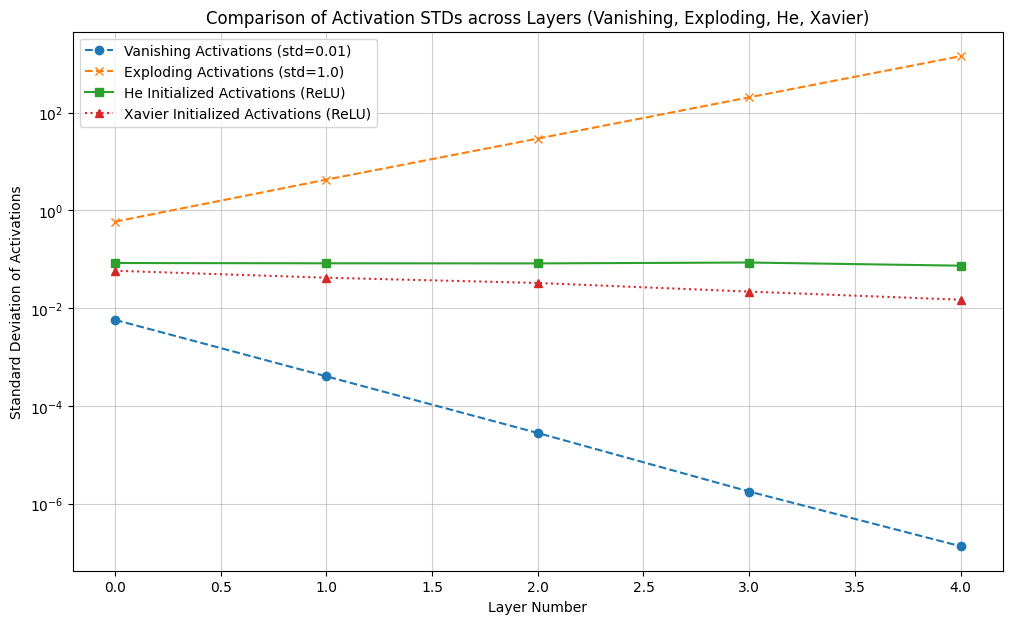

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(layers, vanishing_stds, label='Vanishing Activations (std=0.01)', marker='o', linestyle='--')
plt.plot(layers, exploding_stds, label='Exploding Activations (std=1.0)', marker='x', linestyle='--')
plt.plot(layers, he_stds, label='He Initialized Activations (ReLU)', marker='s')
plt.plot(layers, xavier_stds, label='Xavier Initialized Activations (ReLU)', marker='^', linestyle=':')

plt.title('Comparison of Activation STDs across Layers (Vanishing, Exploding, He, Xavier)')
plt.xlabel('Layer Number')
plt.ylabel('Standard Deviation of Activations')
plt.yscale('log') # Use a log scale for better visualization due to large differences
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

#Advance optimization

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

# Global seed — re-applied before every training run so each optimizer
# starts from identical weight initialization and sees the same shuffle order.
SEED = 42
tf.keras.utils.set_random_seed(SEED)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test,  10)

class_names = ['airplane', 'automobile', 'bird',  'cat',  'deer',
               'dog',      'frog',       'horse', 'ship', 'truck']

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}, y_test:  {y_test.shape}")

Exception: URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 503 -- Service Unavailable

NameError: name 'x_train' is not defined

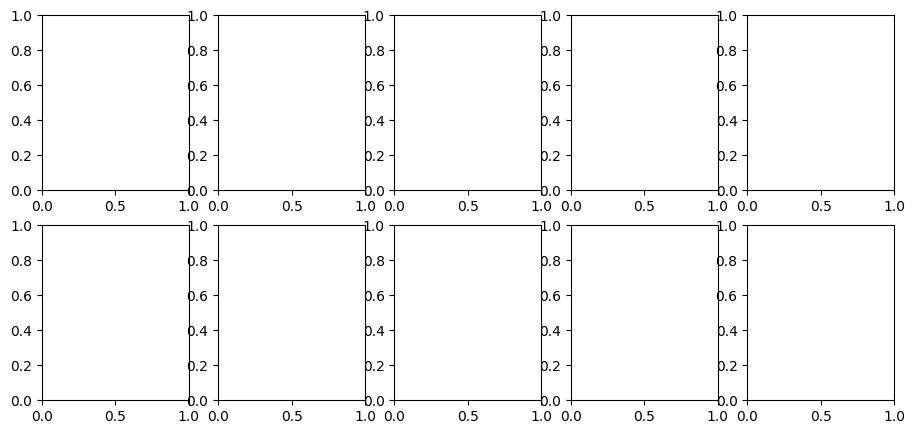

In [ ]:

# Peek at a handful of images
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(np.argmax(y_train[i]))])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ])
    return model

build_model().summary()

In [ ]:
EPOCHS      = 15
BATCH_SIZE  = 128

histories = {}

def train_with(optimizer, name):
    # Reset all RNGs so weight init + shuffling are identical across runs.
    tf.keras.utils.set_random_seed(SEED)

    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    print(f"\n=== Training with {name} ===")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )
    histories[name] = history.history
    return history

In [ ]:
train_with(keras.optimizers.SGD(learning_rate=0.01), 'SGD')


In [ ]:
train_with(keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), 'Momentum')

In [ ]:
train_with(keras.optimizers.RMSprop(learning_rate=0.001), 'RMSprop')

NameError: name 'train_with' is not defined

In [ ]:
train_with(keras.optimizers.Adam(learning_rate=0.001), 'Adam')

NameError: name 'train_with' is not defined

NameError: name 'histories' is not defined

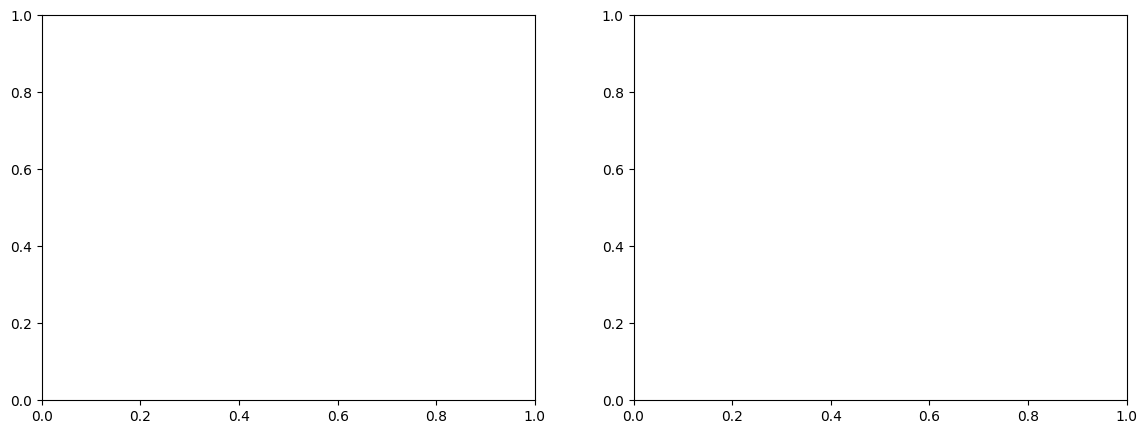

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'SGD': '#d62728', 'Momentum': '#ff7f0e',
          'RMSprop': '#2ca02c', 'Adam': '#1f77b4'}

for name, h in histories.items():
    axes[0].plot(h['loss'],         label=name, color=colors.get(name), linewidth=2)
    axes[1].plot(h['val_accuracy'], label=name, color=colors.get(name), linewidth=2)

axes[0].set(xlabel='Epoch', ylabel='Training loss', title='Training loss')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set(xlabel='Epoch', ylabel='Validation accuracy', title='Validation accuracy')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

#Deep dive into advanced optimizer, 24seven case study

divide the stores into classes for better inventory management and customer handling.

In [ ]:
!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2


Downloading...
From: https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
To: /content/multiclass.csv
100% 14.6k/14.6k [00:00<00:00, 48.2MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/multiclass.csv")
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


In [ ]:
df.shape

(440, 8)

In [ ]:
df = pd.get_dummies(df, columns = ["class", "Region"])
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class_1,class_2,class_3,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,True,False,False,False,True
1,7057,9810,9568,1762,3293,1776,False,True,False,False,False,True
2,6353,8808,7684,2405,3516,7844,False,True,False,False,False,True
3,13265,1196,4221,6404,507,1788,True,False,False,False,False,True
4,22615,5410,7198,3915,1777,5185,True,False,False,False,False,True


In [ ]:
x = df.drop(columns=["class_1","class_2","class_3"])
y= df[["class_1","class_2","class_3"]]

In [ ]:
y.head()

,class_1,class_2,class_3
0,False,True,False
1,False,True,False
2,False,True,False
3,True,False,False
4,True,False,False


In [ ]:
x.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,False,True
1,7057,9810,9568,1762,3293,1776,False,False,True
2,6353,8808,7684,2405,3516,7844,False,False,True
3,13265,1196,4221,6404,507,1788,False,False,True
4,22615,5410,7198,3915,1777,5185,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(x, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

print('Train : ', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (356, 9) (356, 3)
Validation: (40, 9) (40, 3)
Test  :  (44, 9) (44, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


# For Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
def create_baseline():

  model = Sequential([
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(128, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(3,activation='softmax')])
  return model

In [ ]:
model = create_baseline()

Using MiniBatch GD as Optimizer

In [ ]:
model.compile(optimizer = tf.keras.optimizers.SGD(),
                loss = tf.keras.losses.CategoricalCrossentropy() )

In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=10, batch_size=128)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 888ms/step - loss: 1.1089 - val_loss: 1.1103
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1040 - val_loss: 1.1041
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0991 - val_loss: 1.0978
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0942 - val_loss: 1.0916
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0894 - val_loss: 1.0856
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.0846 - val_loss: 1.0796
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0799 - val_loss: 1.0736
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0752 - val_loss: 1.0678
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0705 - val_loss: 1.0621
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0660 - val_loss: 1.0567


In [ ]:
epochs = history.epoch

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']

<function matplotlib.pyplot.show(close=None, block=None)>

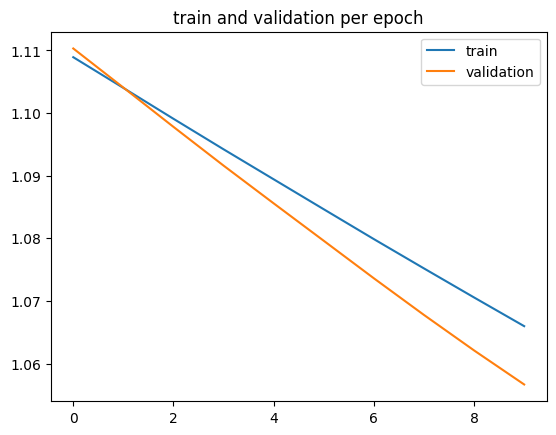

In [ ]:
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")
plt.legend()
plt.title("train and validation per epoch")
plt.show

increase num of epochs to 200 from 10

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.0615 - val_loss: 1.0512
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0570 - val_loss: 1.0459
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0527 - val_loss: 1.0406
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.0483 - val_loss: 1.0353
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0440 - val_loss: 1.0299
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.0398 - val_loss: 1.0244
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.0354 - val_loss: 1.0189
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.0310 - val_loss: 1.0133
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.0266 - val_loss: 1.0078
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0221 - val_loss: 1.0023
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0177 - val_loss: 0.9967
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0132 - val_lo

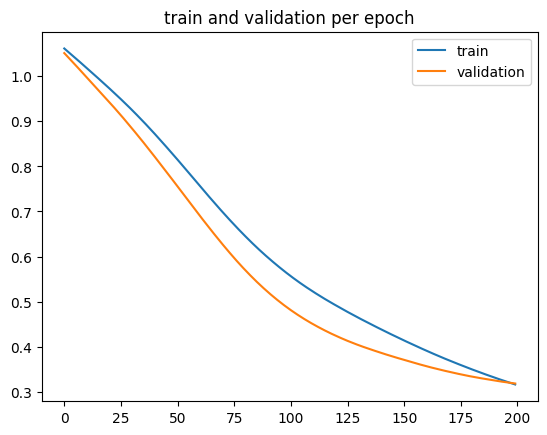

In [ ]:
history_200epoch = model.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=200, batch_size=128)
epochs = history_200epoch.epoch
loss = history_200epoch.history['loss']
val_loss = history_200epoch.history['val_loss']
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")
plt.legend()
plt.title("train and validation per epoch")
plt.show()

to reduce loss too many number of epochs are needed which is a huge oeverhead specially when data is large. We can improve it uding better optimizers.

##GD with momentum

In [ ]:
model_gdm = create_baseline()

In [ ]:
model_gdm.compile(optimizer = tf.keras.optimizers.SGD(momentum=0.9),
                loss = tf.keras.losses.CategoricalCrossentropy() )

In [ ]:
history_gdm = model_gdm.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)

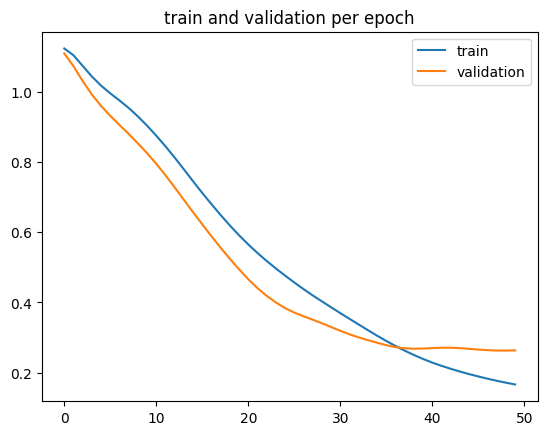

In [ ]:
epochs = history_gdm.epoch
loss = history_gdm.history['loss']
val_loss = history_gdm.history['val_loss']
plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")
plt.legend()
plt.title("train and validation per epoch")
plt.show()

Just by using Momentum with Gradient Descent:

The model was able to perform so much better in just 25 epochs

In [ ]:
model_rms = create_baseline()

In [ ]:
model_rms.compile(optimizer = tf.keras.optimizers.RMSprop(rho=0.9),
                loss = tf.keras.losses.CategoricalCrossentropy())

In [ ]:
history = model_rms.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)

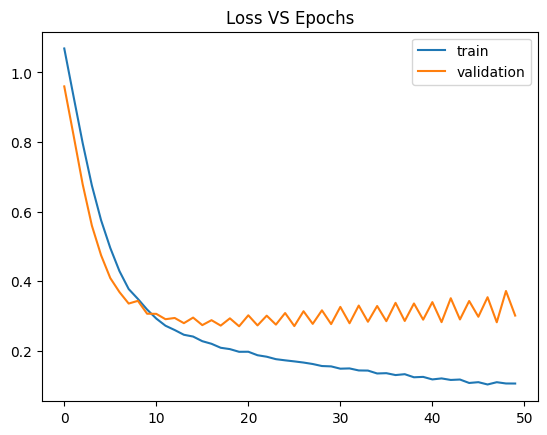

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()

Though RMSProp reaches minima within 10 training epochs:

we see a lot of oscillations than Gradient Descent with momentum
meaning the optimizer still takes steps in the direction not to the global minima

In [ ]:
model_adam = create_baseline()

In [ ]:
model_adam.compile(optimizer = tf.keras.optimizers.Adam(beta_1 = 0.9, beta_2 = 0.999 ),
                loss = tf.keras.losses.CategoricalCrossentropy() )


In [ ]:
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)

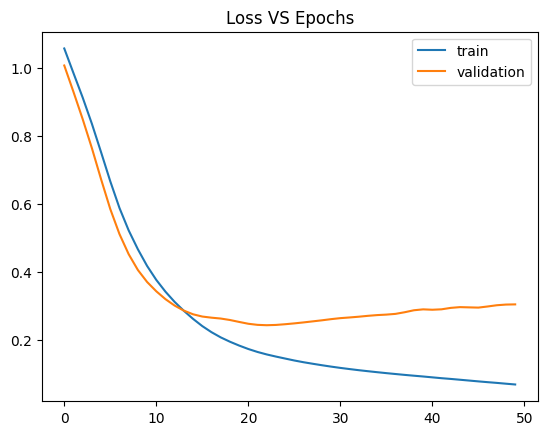

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()


#using learning rate decay on top of adam optimizer

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

In [ ]:
def scheduler(epoch, lr):
  r_0 = 0.01
  lr = (1/(1+r_0*epoch))*lr

  return lr

In [ ]:
LRdecay = LearningRateScheduler(scheduler)

In [ ]:
model_adam = create_baseline()

In [ ]:
model_adam.compile(optimizer = tf.keras.optimizers.Adam(beta_1 = 0.9, beta_2 = 0.999 ),
                loss = tf.keras.losses.CategoricalCrossentropy() )


In [ ]:
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128,callbacks=[LRdecay], verbose = 0)


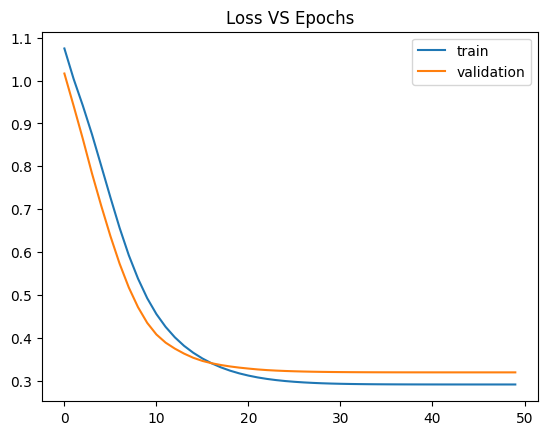

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



#Callbacks


In [ ]:
from pathlib import Path
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger,
)

ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

CKPT_PATH = ARTIFACTS / 'best_model.keras'
LOG_PATH  = ARTIFACTS / 'training_log.csv'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(CKPT_PATH),
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    CSVLogger(str(LOG_PATH)),
]

for cb in callbacks:
    print(f"  - {type(cb).__name__}")


  - EarlyStopping
  - ModelCheckpoint
  - ReduceLROnPlateau
  - CSVLogger


In [ ]:
MAX_EPOCHS = 50

tf.keras.utils.set_random_seed(SEED)

clean_model = create_baseline()
clean_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128,callbacks= callbacks, verbose = 2)


print(f"\nStopped after {len(history.history['loss'])} epochs "
      f"(cap was {MAX_EPOCHS}).")


Epoch 1/50

Epoch 1: val_loss improved from None to 0.31973, saving model to artifacts/best_model.keras

Epoch 1: finished saving model to artifacts/best_model.keras
3/3 - 0s - 126ms/step - loss: 0.2915 - val_loss: 0.3197 - learning_rate: 2.4502e-08
Epoch 2/50

Epoch 2: val_loss improved from 0.31973 to 0.31973, saving model to artifacts/best_model.keras

Epoch 2: finished saving model to artifacts/best_model.keras
3/3 - 0s - 49ms/step - loss: 0.2915 - val_loss: 0.3197 - learning_rate: 2.4502e-08
Epoch 3/50

Epoch 3: val_loss improved from 0.31973 to 0.31973, saving model to artifacts/best_model.keras

Epoch 3: finished saving model to artifacts/best_model.keras
3/3 - 0s - 48ms/step - loss: 0.2915 - val_loss: 0.3197 - learning_rate: 2.4502e-08
Epoch 4/50

Epoch 4: val_loss improved from 0.31973 to 0.31973, saving model to artifacts/best_model.keras

Epoch 4: finished saving model to artifacts/best_model.keras
3/3 - 0s - 50ms/step - loss: 0.2915 - val_loss: 0.3197 - learning_rate: 2.450

In [ ]:
df = pd.read_csv('artifacts/training_log.csv')
df.head()


,epoch,learning_rate,loss,val_loss
0,0,2.450200e-08,0.291504,0.319727
1,1,2.450200e-08,0.291503,0.319726
2,2,2.450200e-08,0.291502,0.319726
3,3,2.450200e-08,0.291502,0.319725
4,4,2.450200e-08,0.291501,0.319725
